# Two-sided channel LBM — v0.3

Change from v0.2: the upper and lower boundaries are now **free-slip / specular-reflection walls**. Cylinder elements remain **no-slip bounce-back** boundaries.

For the slip walls, the normal lattice-velocity component is reversed while the tangential component is preserved.

In [1]:

%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.widgets import Slider, RadioButtons, Button


In [2]:

class LBMChannel:
    """
    D2Q9 BGK lattice-Boltzmann prototype for a two-sided vegetated channel.

    Boundary conditions:
      - upper/lower walls: free-slip (specular reflection),
      - cylinders: no-slip bounce-back,
      - inlet: prescribed equilibrium velocity,
      - outlet: simple zero-gradient copy.
    """

    W = np.array([
        4/9,
        1/9, 1/9, 1/9, 1/9,
        1/36, 1/36, 1/36, 1/36
    ], dtype=float)

    CX = np.array([0, 1, 0, -1, 0, 1, -1, -1, 1], dtype=int)
    CY = np.array([0, 0, 1, 0, -1, 1, 1, -1, -1], dtype=int)

    # Full bounce-back: reverses both x and y velocity components.
    # Used for no-slip cylinders.
    OPP = np.array([0, 3, 4, 1, 2, 7, 8, 5, 6], dtype=int)

    # Specular reflection at horizontal walls:
    # preserve cx, reverse cy.
    # Used for free-slip upper/lower boundaries.
    SPECULAR_Y = np.array([0, 1, 4, 3, 2, 8, 7, 6, 5], dtype=int)

    CYLINDERS_PER_SIDE = {
        "Low": 45,
        "High": 90,
    }

    def __init__(
        self,
        Nx=220,
        Ny=80,
        omega=1.70,
        u_in=0.06,
        channel_width=28,
        density="Low",
        cylinder_radius=2,
        seed=42,
        vegetation_x=(50, 185),
    ):
        self.Nx = int(Nx)
        self.Ny = int(Ny)
        self.omega = float(omega)
        self.u_in = float(u_in)
        self.channel_width = int(channel_width)
        self.density = density
        self.cylinder_radius = int(cylinder_radius)
        self.seed = int(seed)
        self.vegetation_x = tuple(vegetation_x)

        self.cylinders = None
        self.slip_walls = None
        self.obstacles = None

        self.rho = None
        self.ux = None
        self.uy = None
        self.f = None

        self.build_obstacles()
        self.reset_flow()

    @property
    def nu_lattice(self):
        """BGK kinematic viscosity in lattice units."""
        return (1.0 / self.omega - 0.5) / 3.0

    def equilibrium(self, rho, ux, uy):
        """D2Q9 equilibrium distribution."""
        cu = 3.0 * (
            self.CX[:, None, None] * ux[None, :, :]
            + self.CY[:, None, None] * uy[None, :, :]
        )

        u2 = ux**2 + uy**2

        return (
            self.W[:, None, None]
            * rho[None, :, :]
            * (
                1.0
                + cu
                + 0.5 * cu**2
                - 1.5 * u2[None, :, :]
            )
        )

    def _place_cylinders(self, cyl, side, n_target, rng):
        """Random sequential placement of circular elements."""
        r = self.cylinder_radius
        x0, x1 = self.vegetation_x

        y_mid = 0.5 * (self.Ny - 1)
        half_channel = 0.5 * self.channel_width

        if side == "lower":
            y_min = 2 + r
            y_max = int(np.floor(y_mid - half_channel)) - r - 2
        else:
            y_min = int(np.ceil(y_mid + half_channel)) + r + 2
            y_max = self.Ny - 3 - r

        x_min = x0 + r
        x_max = x1 - r - 1

        if y_max <= y_min or x_max <= x_min:
            return

        centers = []
        min_sep2 = (2 * r + 1)**2
        attempts = 0
        max_attempts = 100 * n_target

        while len(centers) < n_target and attempts < max_attempts:
            attempts += 1

            x = int(rng.integers(x_min, x_max + 1))
            y = int(rng.integers(y_min, y_max + 1))

            if centers:
                c = np.asarray(centers)
                d2 = (
                    (c[:, 0] - x)**2
                    + (c[:, 1] - y)**2
                )

                if np.any(d2 < min_sep2):
                    continue

            centers.append((x, y))

        for x, y in centers:
            yy0 = y - r
            yy1 = y + r + 1
            xx0 = x - r
            xx1 = x + r + 1

            yy, xx = np.ogrid[yy0:yy1, xx0:xx1]

            disk = (
                (xx - x)**2
                + (yy - y)**2
                <= r**2
            )

            cyl[yy0:yy1, xx0:xx1] |= disk

    def build_obstacles(self):
        """
        Build separate masks for:
          1. no-slip cylinders,
          2. free-slip horizontal walls.
        """
        cylinders = np.zeros(
            (self.Ny, self.Nx),
            dtype=bool
        )

        slip_walls = np.zeros(
            (self.Ny, self.Nx),
            dtype=bool
        )

        # Horizontal outer boundaries are slip walls.
        slip_walls[0, :] = True
        slip_walls[-1, :] = True

        rng = np.random.default_rng(self.seed)
        n = self.CYLINDERS_PER_SIDE[self.density]

        self._place_cylinders(
            cylinders, "lower", n, rng
        )

        self._place_cylinders(
            cylinders, "upper", n, rng
        )

        self.cylinders = cylinders
        self.slip_walls = slip_walls

        # Combined mask only for visualization and excluding
        # boundary nodes from inlet/outlet assignment.
        self.obstacles = cylinders | slip_walls

    def reset_flow(self):
        """Return flow to uniform initial condition."""
        self.rho = np.ones(
            (self.Ny, self.Nx),
            dtype=float
        )

        self.ux = np.full(
            (self.Ny, self.Nx),
            self.u_in,
            dtype=float
        )

        self.uy = np.zeros(
            (self.Ny, self.Nx),
            dtype=float
        )

        # Boundary-node velocities are not physical fluid values.
        self.ux[self.obstacles] = 0.0
        self.uy[self.obstacles] = 0.0

        self.f = self.equilibrium(
            self.rho,
            self.ux,
            self.uy
        )

    def set_geometry(
        self,
        density=None,
        channel_width=None
    ):
        """Change geometry and restart flow."""
        if density is not None:
            self.density = density

        if channel_width is not None:
            self.channel_width = int(channel_width)

        self.build_obstacles()
        self.reset_flow()

    def set_inflow(self, u_in):
        """Change inlet speed without rebuilding geometry."""
        self.u_in = float(u_in)

    def _update_macroscopic(self):
        self.rho = np.sum(
            self.f,
            axis=0
        )

        self.rho = np.maximum(
            self.rho,
            1e-12
        )

        self.ux = (
            np.sum(
                self.f * self.CX[:, None, None],
                axis=0
            )
            / self.rho
        )

        self.uy = (
            np.sum(
                self.f * self.CY[:, None, None],
                axis=0
            )
            / self.rho
        )

        self.ux[self.obstacles] = 0.0
        self.uy[self.obstacles] = 0.0

    def step(self, n_steps=1):
        """Advance solution by n_steps lattice steps."""
        for _ in range(int(n_steps)):

            # ---------------------------------
            # 1. Macroscopic fields
            # ---------------------------------
            rho = np.sum(self.f, axis=0)
            rho = np.maximum(rho, 1e-12)

            ux = (
                np.sum(
                    self.f * self.CX[:, None, None],
                    axis=0
                )
                / rho
            )

            uy = (
                np.sum(
                    self.f * self.CY[:, None, None],
                    axis=0
                )
                / rho
            )

            ux[self.obstacles] = 0.0
            uy[self.obstacles] = 0.0

            # ---------------------------------
            # 2. BGK collision
            # ---------------------------------
            feq = self.equilibrium(
                rho,
                ux,
                uy
            )

            f_post = (
                self.f
                - self.omega
                * (self.f - feq)
            )

            # ---------------------------------
            # 3. Streaming
            # ---------------------------------
            f_new = np.empty_like(self.f)

            for i in range(9):
                f_new[i] = np.roll(
                    np.roll(
                        f_post[i],
                        self.CX[i],
                        axis=1
                    ),
                    self.CY[i],
                    axis=0
                )

            streamed = f_new.copy()

            # ---------------------------------
            # 4a. No-slip bounce-back on cylinders
            # ---------------------------------
            for i in range(9):
                f_new[
                    i,
                    self.cylinders
                ] = streamed[
                    self.OPP[i],
                    self.cylinders
                ]

            # ---------------------------------
            # 4b. Free-slip / specular reflection
            #     on upper and lower boundaries
            #
            #     cx is preserved
            #     cy changes sign
            # ---------------------------------
            for i in range(9):
                f_new[
                    i,
                    self.slip_walls
                ] = streamed[
                    self.SPECULAR_Y[i],
                    self.slip_walls
                ]

            # ---------------------------------
            # 5. Simple equilibrium inlet
            # ---------------------------------
            rho_in = np.ones(
                (self.Ny, 1),
                dtype=float
            )

            ux_in = np.full(
                (self.Ny, 1),
                self.u_in,
                dtype=float
            )

            uy_in = np.zeros(
                (self.Ny, 1),
                dtype=float
            )

            f_in = self.equilibrium(
                rho_in,
                ux_in,
                uy_in
            )[:, :, 0]

            fluid_left = ~self.obstacles[:, 0]

            f_new[
                :,
                fluid_left,
                0
            ] = f_in[
                :,
                fluid_left
            ]

            # ---------------------------------
            # 6. Simple zero-gradient outlet
            # ---------------------------------
            fluid_right = ~self.obstacles[:, -1]

            f_new[
                :,
                fluid_right,
                -1
            ] = f_new[
                :,
                fluid_right,
                -2
            ]

            self.f = f_new

        self._update_macroscopic()

    def speed(self):
        return np.sqrt(
            self.ux**2 + self.uy**2
        )

    def vorticity(self):
        """omega_z = dv/dx - du/dy"""
        return (
            np.gradient(self.uy, axis=1)
            - np.gradient(self.ux, axis=0)
        )


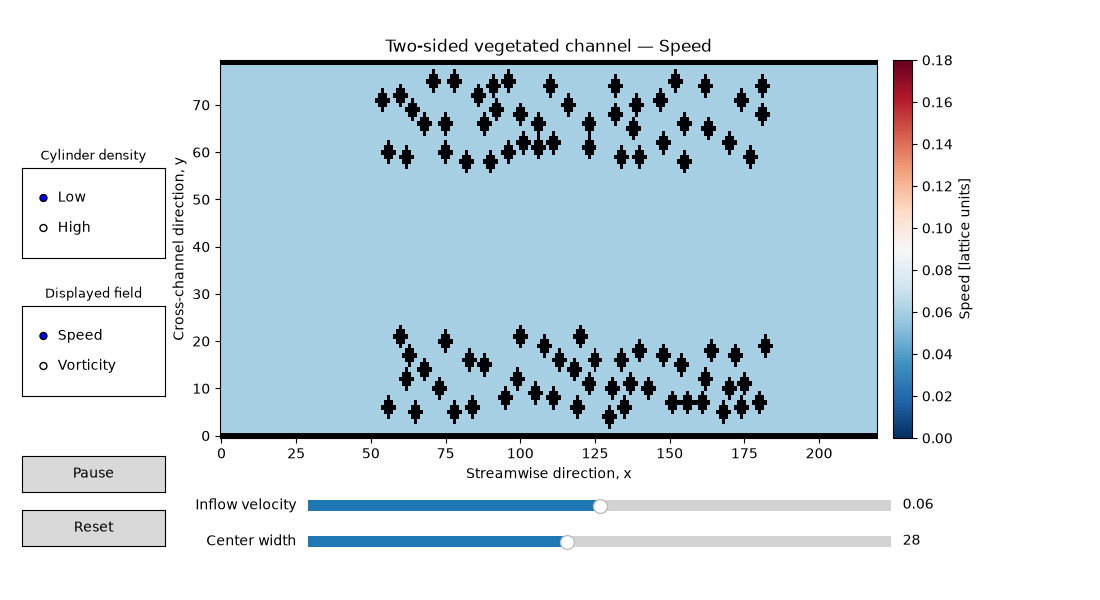

In [3]:

# ============================================================
# INITIALIZE SIMULATION
# ============================================================

sim = LBMChannel(
    Nx=220,
    Ny=80,
    omega=1.70,
    u_in=0.06,
    channel_width=28,
    density="Low",
    cylinder_radius=2,
    vegetation_x=(50, 185),
)

STEPS_PER_FRAME = 4

current_field = "Speed"
running = True


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

plt.subplots_adjust(
    left=0.20,
    right=0.92,
    bottom=0.27,
    top=0.90
)

img = ax.imshow(
    sim.speed(),
    origin="lower",
    cmap="RdBu_r",
    vmin=0.0,
    vmax=0.18,
    interpolation="nearest",
    aspect="auto"
)

img_obs = ax.imshow(
    np.where(sim.obstacles, 1.0, np.nan),
    origin="lower",
    cmap="gray_r",
    vmin=0.0,
    vmax=1.0,
    alpha=0.95,
    interpolation="nearest",
    aspect="auto"
)

ax.set_xlabel("Streamwise direction, x")
ax.set_ylabel("Cross-channel direction, y")

title = ax.set_title(
    "Two-sided vegetated channel — Speed"
)

cbar = fig.colorbar(
    img,
    ax=ax,
    pad=0.02
)

cbar.set_label("Speed [lattice units]")


# ============================================================
# CONTROLS
# ============================================================

ax_velocity = plt.axes(
    [0.28, 0.14, 0.53, 0.035]
)

velocity_slider = Slider(
    ax=ax_velocity,
    label="Inflow velocity",
    valmin=0.02,
    valmax=0.10,
    valinit=sim.u_in,
    valstep=0.005
)


ax_width = plt.axes(
    [0.28, 0.08, 0.53, 0.035]
)

width_slider = Slider(
    ax=ax_width,
    label="Center width",
    valmin=12,
    valmax=48,
    valinit=sim.channel_width,
    valstep=2
)


ax_density = plt.axes(
    [0.02, 0.57, 0.13, 0.15]
)

density_radio = RadioButtons(
    ax_density,
    ("Low", "High"),
    active=0
)

ax_density.set_title(
    "Cylinder density",
    fontsize=9
)


ax_field = plt.axes(
    [0.02, 0.34, 0.13, 0.15]
)

field_radio = RadioButtons(
    ax_field,
    ("Speed", "Vorticity"),
    active=0
)

ax_field.set_title(
    "Displayed field",
    fontsize=9
)


ax_run = plt.axes(
    [0.02, 0.18, 0.13, 0.06]
)

run_button = Button(
    ax_run,
    "Pause"
)


ax_reset = plt.axes(
    [0.02, 0.09, 0.13, 0.06]
)

reset_button = Button(
    ax_reset,
    "Reset"
)


# ============================================================
# CALLBACKS
# ============================================================

def refresh_obstacles():
    img_obs.set_data(
        np.where(
            sim.obstacles,
            1.0,
            np.nan
        )
    )

    fig.canvas.draw_idle()


def change_velocity(value):
    sim.set_inflow(
        velocity_slider.val
    )


def change_width(value):
    sim.set_geometry(
        density=sim.density,
        channel_width=int(width_slider.val)
    )

    refresh_obstacles()


def change_density(label):
    sim.set_geometry(
        density=label,
        channel_width=sim.channel_width
    )

    refresh_obstacles()


def change_field(label):
    global current_field
    current_field = label


def toggle_run(event):
    global running

    running = not running

    if running:
        run_button.label.set_text("Pause")
    else:
        run_button.label.set_text("Run")


def reset_flow(event):
    sim.reset_flow()
    fig.canvas.draw_idle()


velocity_slider.on_changed(change_velocity)
width_slider.on_changed(change_width)
density_radio.on_clicked(change_density)
field_radio.on_clicked(change_field)
run_button.on_clicked(toggle_run)
reset_button.on_clicked(reset_flow)


# ============================================================
# ANIMATION
# ============================================================

def animate(frame):

    if running:
        sim.step(STEPS_PER_FRAME)

    if current_field == "Speed":

        data = sim.speed()

        img.set_data(data)
        img.set_cmap("PRGn")
        img.set_clim(0.0, 0.18)

        title.set_text(
            "Two-sided vegetated channel — Speed"
        )

        cbar.set_label(
            "Speed [lattice units]"
        )

    else:

        data = sim.vorticity()

        img.set_data(data)
        img.set_cmap("RdBu_r")
        img.set_clim(-0.035, 0.035)

        title.set_text(
            "Two-sided vegetated channel — Vorticity"
        )

        cbar.set_label(
            "Vorticity [lattice units]"
        )

    return img, img_obs


ani = animation.FuncAnimation(
    fig,
    animate,
    interval=40,
    blit=False,
    cache_frame_data=False
)

plt.show()
